# Cyber Security per la sanità tramite Reinforcement Learning

DeepGuard Inc., un'azienda leader nel settore della sicurezza informatica per le industrie sanitarie, si trova a fronteggiare un aumento della complessità e sofisticazione degli attacchi informatici. La necessità di proteggere le informazioni sensibili dei pazienti e garantire la conformità normativa è cruciale per mantenere la fiducia dei clienti e la sicurezza dei dati.

**Benefici del Progetto:**  
L'implementazione di algoritmi avanzati di Reinforcement Learning per simulare e mitigare scenari di attacco e difesa offre vantaggi significativi:

- **Miglioramento della Difesa:** Addestramento di agenti difensivi in scenari simulati per sviluppare strategie di protezione robuste e adattabili.
- **Identificazione delle Vulnerabilità:** Simulazione di attacchi per identificare e risolvere vulnerabilità nei sistemi di rete prima che possano essere sfruttate da attaccanti reali.
- **Innovazione Tecnologica:** Utilizzo di tecniche avanzate di Reinforcement Learning per promuovere l'innovazione e migliorare continuamente le capacità di difesa informatica.
- **Ottimizzazione delle Risorse:** Automatizzazione della simulazione di attacchi e difese per ridurre il carico di lavoro umano e ottimizzare l'allocazione delle risorse aziendali.

**Dettagli del Progetto:**  
GreenGuard Solutions ha incaricato lo sviluppo di una soluzione avanzata per la sicurezza informatica basata su algoritmi di Reinforcement Learning. Il progetto si focalizza sull'applicazione di due principali algoritmi all'interno dell'ambiente gym-idsgame, specializzato in simulazioni di attacco e difesa in reti informatiche.

**Obiettivi del Progetto:**

- **Algoritmo SARSA:** Utilizzare SARSA per affrontare scenari di "random attack" nell'ambiente gym-idsgame.
- **Algoritmo DDQN:** Implementare Double Deep Q-Network (DDQN) con PyTorch per risolvere scenari di "random attack" e "maximal attack".

**Deliverable:**  
Il progetto richiede la consegna di un notebook Google Colab suddiviso in due sezioni principali, ciascuna dedicata a uno dei due algoritmi di Reinforcement Learning. Ogni sezione dovrà contenere spiegazioni dettagliate delle soluzioni proposte, motivando le scelte effettuate e analizzando i risultati ottenuti.

**Motivazione del Progetto:**  
GreenGuard Solutions pone la massima priorità sulla sicurezza informatica nel settore sanitario. L'utilizzo di algoritmi avanzati di Reinforcement Learning per simulare e mitigare rischi cibernetici consente all'azienda di rafforzare le sue capacità difensive e proteggere le reti di computer contro attacchi sempre più sofisticati. Automatizzando la simulazione di attacchi, GreenGuard ottimizza l'efficienza operativa e si conferma come leader nell'innovazione tecnologica per la sicurezza informatica nel settore sanitario.

# Implementazione

## Import delle dipendenze

In [1]:
# GymGames download and installation

!git clone https://github.com/Limmen/gym-idsgame
!pip3 install -e ./gym-idsgame

fatal: destination path 'gym-idsgame' already exists and is not an empty directory.


Obtaining file:///C:/Repositories/proai/course8-rl/project/gym-idsgame
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for gym_idsgame (pyproject.toml): started
  Building editable for gym_idsgame (pyproject.toml): finished with status 'done'
  Created wheel for gym_idsgame: filename=gym_idsgame-1.0.12-0.editable-py3-none-any.whl size=4215 sha256=59b2f78237dd90e4cdea14a14e4e466b7b937b6bc3e0588d368935ffd10552b1
  Stored in directory: C:\Users\GabrieleScorpaniti\AppData\Local\Temp\pip-ephem-wheel-cache-zhsf_cyr\wheels\bb\46\50\7

In [2]:
#Dependencies imports

#Generics
import numpy as np
import matplotlib.pyplot as plt
import random
import os

#OAI Gym
import gymnasium as gym
from gym.wrappers.record_video import RecordVideo

#Torch
import torch
import torch.nn as nn
from collections import deque

from torchsummary import summary

#Gym Environment
%cd gym-idsgame/
from gym_idsgame.envs import IdsGameRandomAttackV21Env
from gym_idsgame.envs import IdsGameMaximalAttackV21Env
from gym_idsgame.envs.dao.game_config import GameConfig
from gym_idsgame.envs.dao.idsgame_config import IdsGameConfig
from gym_idsgame.agents.bot_agents.random_attack_bot_agent import RandomAttackBotAgent
from gym_idsgame.agents.bot_agents.attack_maximal_value_bot_agent import AttackMaximalValueBotAgent

c:\Repositories\proai\course8-rl\project\gym-idsgame


In [3]:
SEED = 52

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
gym.utils.seeding.np_random(SEED)

(Generator(PCG64) at 0x2658E1FB920, 52)

In [4]:
# Hyperparameters

GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.1
EPSILON_DECAY = 1000
LEARNING_RATE = 0.0003
BATCH_SIZE = 64
TARGET_UPDATE = 1000
MEMORY_SIZE = 100000
NUM_EPISODES = 300

In [5]:
VIDEO_PATH = "./videos"

if not os.path.exists(VIDEO_PATH):
    os.makedirs(VIDEO_PATH)

In [6]:
IMAGES_PATH = "./images"

if not os.path.exists(IMAGES_PATH):
    os.makedirs(IMAGES_PATH)

## Algorithms

In [7]:
class DQN(nn.Module):
    """
    Deep Q-Network model definition.

    Args:
        input_shape (int): Dimension of the input state.
        num_actions (int): Number of possible actions.
    """

    def __init__(self, input_shape, num_actions):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_shape, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        """
        Forward pass of the network.

        Args:
            x (torch.Tensor): Input tensor.
        Returns:
            torch.Tensor: Output Q-values for each action.
        """
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return x

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
class ReplayBuffer:
    """
    Replay buffer for storing transitions during DDQN training.
    """

    def __init__(self, max_size=100000):
        """
        Initialize the replay buffer.
        Args:
            max_size (int): Maximum number of transitions to store.
        """
        self.memory = deque(maxlen=max_size)

    def push(self, *args):
        """
        Add a transition to the memory.
        Args:
            *args: Transition tuple (state, action, reward, next_state, done).
        """
        self.memory.append(args)

    def sample(self, batch_size):
        """
        Randomly sample a batch of transitions from memory.
        Args:
            batch_size (int): Number of samples to return.
        Returns:
            list: Batch of transitions as arrays.
        """
        batch = random.sample(self.memory, batch_size)

        # print('batch:',batch)

        return [np.array(x) for x in zip(*batch)]

    def __len__(self):
        """
        Return the number of transitions in memory.
        Returns:
            int: Number of transitions stored.
        """
        return len(self.memory)

In [10]:
def select_action(state, epsilon, n_actions, online_net, device):
    """
    Epsilon-greedy action selection for DDQN.

    Args:
        state (np.ndarray): Current state.
        epsilon (float): Exploration rate.
        n_actions (int): Number of possible actions.
        online_net (nn.Module): Online Q-network.
        device (torch.device): Device to use.
    Returns:
        int: Selected action.
    """
    if random.random() > epsilon:
        with torch.no_grad():
            # EXPLOITATION
            state = torch.FloatTensor(state.flatten()).unsqueeze(0).to(device)
            return online_net(state).argmax(1).item()
    else:
        # EXPLORATION
        return random.randrange(n_actions)

In [11]:
def optimize_model(online_dqn, target_dqn, memory, optimizer, batch_size=64, gamma=0.99, device=DEVICE):
    """
    Perform a single optimization step for the online network using DDQN logic.

    Args:
        online_dqn (nn.Module): Online Q-network.
        target_dqn (nn.Module): Target Q-network.
        memory (ReplayBuffer): Experience replay buffer.
        optimizer (torch.optim.Optimizer): Optimizer for the online network.
        batch_size (int): Batch size for optimization.
        gamma (float): Discount factor.
        device (torch.device): Device to use.
    """
    if len(memory) < batch_size:
        return

    state, action, reward, next_state, done = memory.sample(batch_size)

    state = torch.FloatTensor(state).to(device)
    action = torch.LongTensor(action).to(device)
    reward = torch.FloatTensor(reward).to(device)
    next_state = torch.FloatTensor(next_state).to(device)
    done = torch.FloatTensor(done).to(device)

    q_value = online_dqn(state).gather(1, action.unsqueeze(1)).squeeze(1)
    next_actions = online_dqn(next_state).argmax(1).unsqueeze(1)
    next_q_value = target_dqn(next_state).gather(1, next_actions).squeeze(1)
    expected_q_value = reward + gamma * next_q_value * (1 - done)

    loss = (q_value - expected_q_value.detach()).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# END INTERNAL METHODS

In [12]:
import torch.optim as optim

def ddqn(env, online_dqn, target_dqn, memory, target_update, DEVICE=DEVICE):
    """
    Main training loop for Double DQN agent.

    Args:
        env (gym.Env): The environment.
        online_dqn (DQN): Online Q-network.
        target_dqn (DQN): Target Q-network.
        memory (ReplayBuffer): Experience replay buffer.
        target_update (int): Number of episodes between target network updates.
        DEVICE (torch.device): Device to use.
    """
    num_actions = env.defender_action_space.n

    online_optimizer = optim.Adam(online_dqn.parameters(), lr=LEARNING_RATE)

    epsilon = EPSILON_START
    epsilon_decay = (EPSILON_START - EPSILON_END) / EPSILON_DECAY

    steps_done = 0
    episode_rewards = []

    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        # print('state',state)
        # print('state_dim',state.flatten().shape[0])
        total_reward = 0
        for t in range(1000):
            # Epsilon-greedy action selection
            action = select_action(state, epsilon, num_actions, online_dqn, DEVICE)
            next_state, reward, done, _, _ = env.step((0, action))

            # print('reward',reward)
            defender_reward = reward[1]

            state = state.flatten()
            next_state = next_state.flatten()

            if done and defender_reward <= 0:
                reward = -1
            
            total_reward += defender_reward

            # print('state shape: ', state.shape)
            # print('next state shape: ', next_state.shape)

            # Store transition in replay buffer
            memory.push(state, action, defender_reward, next_state, done)

            state = next_state

            # Optimize the online network
            optimize_model(online_dqn, target_dqn, memory, online_optimizer)

            if done:
                break

            epsilon = max(EPSILON_END, epsilon - epsilon_decay)
            steps_done += 1

        # Update target network
        if episode % target_update == 0:
            target_dqn.load_state_dict(online_dqn.state_dict())

        episode_rewards.append(total_reward)
        print(f"Episode {episode + 1}, Total reward: {total_reward}")

    return episode_rewards

In [13]:
def sarsa(env, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.995, episodes=5000, max_steps=100, verbose=False):
    """
    SARSA algorithm for IDSGames (https://github.com/Limmen/gym-idsgame).

    Args:
        env: Gymnasium/OpenAI Gym environment with discrete spaces.
        alpha (float): Learning rate.
        gamma (float): Discount factor.
        epsilon_start (float): Initial exploration rate.
        epsilon_end (float): Final exploration rate.
        epsilon_decay (float): Decay rate for exploration.
        episodes (int): Number of training episodes.
        max_steps (int): Maximum number of steps per episode.
        verbose (bool): If True, print information during learning.
    Returns:
        Q (np.ndarray): Learned Q-table.
        episode_rewards (list): List of total rewards per episode.
    """
    
    n_actions = env.defender_action_space.n
    Q = {}
    episode_rewards = []
    epsilon = epsilon_start

    for ep in range(episodes):
        
        obs = env.reset()[1]
        state = tuple(obs)
        
        done = False
        ep_defender_sum = 0.0

        # Epsilon-greedy policy
        if state not in Q:
            Q[state] = np.zeros(n_actions)

        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q[state])

        for step in range(max_steps):

            next_obs, reward, done, info, _ = env.step((0, action))

            defender_reward = reward[1]

            if verbose:
                print(f"Defender Reward: {defender_reward}")

            ep_defender_sum += defender_reward
            next_def_obs = next_obs[1]

            next_state = tuple(next_def_obs.flatten())

            if next_state not in Q:
                Q[next_state] = np.zeros(n_actions)

            if not done:
                #new policy selection
                if np.random.rand() < epsilon:
                    next_action = np.random.randint(n_actions)
                else:
                    next_action = np.argmax(Q[next_state])
            else:
                next_action = None

            current_q = Q[state][action]

            if not done:
                next_q = Q[next_state][next_action]
                td_target = defender_reward + gamma * next_q
            else:
                td_target = defender_reward

            Q[state][action] += alpha * (td_target - current_q)
            state = next_state
            action = next_action

            if done:
                break

        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(ep_defender_sum)

        if verbose and (ep+1) % 100 == 0:
            print(f'{ep+1} Episodes Passed')

    return Q, episode_rewards

## Scenario 1 - Random Attack with SARSA

In [14]:
#Environment settings

game_config = GameConfig(dense_rewards=False, dense_rewards_v2=False, dense_rewards_v3=False)

In [15]:
#Agent Setup

attacker_agent = RandomAttackBotAgent(game_config=game_config, env=None)

In [16]:
#Game Config Setup

idsgame_config = IdsGameConfig(game_config=game_config, attacker_agent=attacker_agent)

In [17]:
# Initial setup and reset

env = IdsGameRandomAttackV21Env(idsgame_config=idsgame_config)
obs = env.reset()[0]

In [18]:
defender_action_space = env.defender_action_space.n

#Prendi l'observation del defender [0 = attacker, 1 = defender] e calcolane la shape dopo averla resa una lista
state_dim = 44

In [19]:
online_net = DQN(state_dim, defender_action_space)

In [20]:
target_net = DQN(state_dim, defender_action_space)

In [21]:
summary(target_net, (44,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 512]          23,040
            Linear-2                   [-1, 44]          22,572
Total params: 45,612
Trainable params: 45,612
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.17
Estimated Total Size (MB): 0.18
----------------------------------------------------------------


In [29]:
def compute_50_episode_sums(episode_rewards, block_size=50):
    """
    Divide 'episode_rewards' in blocchi di 'block_size' episodi e ne calcola la somma.
    L'ultimo blocco può essere più corto se non ci sono abbastanza episodi.
    Restituisce:
      sums -> lista delle somme per ciascun blocco
      indices -> lista degli indici finali di ciascun blocco (per l'asse x)
    """
    sums = []
    indices = []
    n = len(episode_rewards)
    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        block_sum = np.sum(episode_rewards[start:end])
        sums.append(block_sum)
        indices.append(end)
    return sums, indices

def plot_50_episode_sums(episode_rewards, block_size=50, color='blue'):
    """
    Plotta la somma delle reward ogni 'block_size' episodi.
    """
    sums, indices = compute_50_episode_sums(episode_rewards, block_size)
    plt.figure(figsize=(12, 6))
    plt.plot(indices, sums, marker='o', color=color)
    plt.title(f"Reward totale del difensore ogni {block_size} episodi")
    plt.xlabel(f"Episodio (fine blocco da {block_size})")
    plt.ylabel(f"Somma delle reward in quel blocco")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [23]:
episode_rewards = ddqn(env, online_net, target_net, ReplayBuffer(), TARGET_UPDATE, DEVICE=DEVICE)

Episode 1, Total reward: 1
Episode 2, Total reward: 1
Episode 3, Total reward: -1
Episode 4, Total reward: 1
Episode 5, Total reward: 1
Episode 6, Total reward: 1
Episode 7, Total reward: -1
Episode 8, Total reward: 1
Episode 9, Total reward: 1
Episode 10, Total reward: 1
Episode 11, Total reward: 1
Episode 12, Total reward: 1
Episode 13, Total reward: 1
Episode 14, Total reward: -1
Episode 15, Total reward: 1
Episode 16, Total reward: 1
Episode 17, Total reward: 1
Episode 18, Total reward: 1
Episode 19, Total reward: 1
Episode 20, Total reward: 1
Episode 21, Total reward: 1
Episode 22, Total reward: 1
Episode 23, Total reward: 1
Episode 24, Total reward: 1
Episode 25, Total reward: 1
Episode 26, Total reward: 1
Episode 27, Total reward: 1
Episode 28, Total reward: 1
Episode 29, Total reward: 1
Episode 30, Total reward: 1
Episode 31, Total reward: 1
Episode 32, Total reward: -1
Episode 33, Total reward: 1
Episode 34, Total reward: 1
Episode 35, Total reward: 1
Episode 36, Total reward:

In [24]:
episode_rewards = np.array(episode_rewards).flatten()

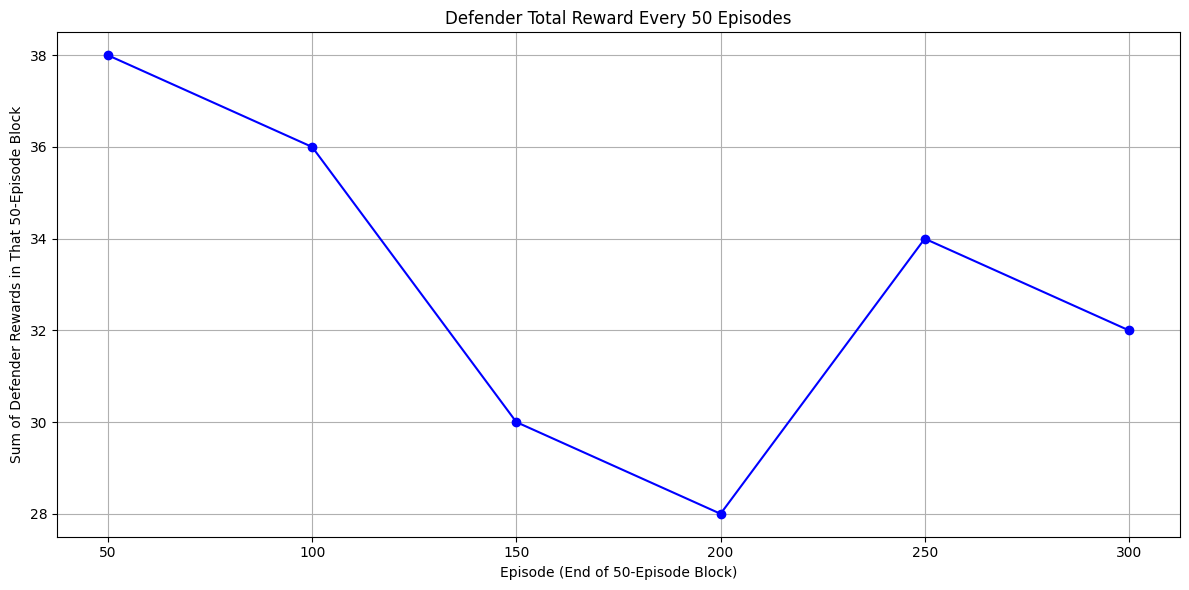

In [25]:
plot_50_episode_sums(episode_rewards)

In [26]:
# Training

Q, episode_rewards = sarsa(env)

In [27]:
episode_rewards = np.array(episode_rewards).flatten()

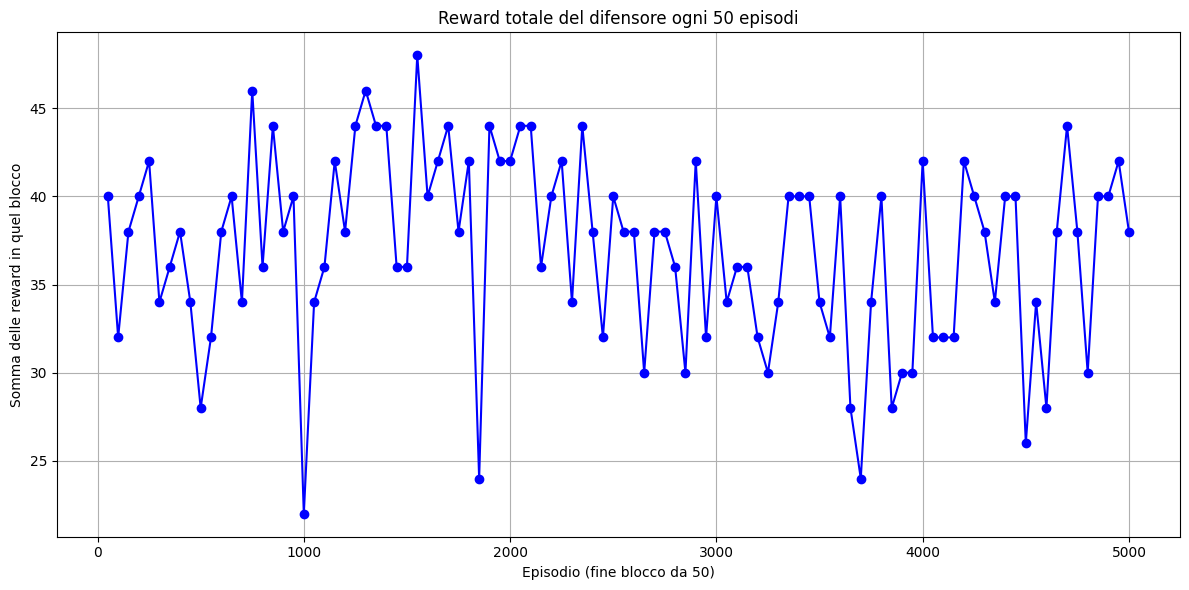

In [30]:
plot_50_episode_sums(episode_rewards)

In [ ]:
#Plots rewards

## Scenario 2 - Random & Maximal Attack with DDQN